In [1]:
import pandas as pd
import psycopg

IMPULSE_LEVELS = [
    0.02,
    0.03,
    0.05,
    0.07,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40,
    0.50
]

In [2]:
query = """
SELECT
    timestamp,
    open,
    high,
    low,
    close,
    volume
FROM candles
ORDER BY timestamp
"""

with psycopg.connect("dbname=dailyedge_development") as connection:
    df = pd.read_sql(query, connection)

df["Datetime"] = pd.to_datetime(df["timestamp"])
df = df.drop(columns=["timestamp"])

print(f"{len(df):,} rows loaded")
df.head()

/tmp/ipykernel_154832/2604799363.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


5,884,751 rows loaded


,open,high,low,close,volume,Datetime
0,1416.299899,1416.299899,1416.299899,1416.299899,1,2008-12-11 01:38:00
1,1412.231742,1412.231742,1412.231742,1412.231742,1,2008-12-11 01:52:00
2,1410.197663,1410.197663,1408.744750,1408.744750,5,2008-12-11 02:14:00
3,1408.454167,1408.454167,1408.454167,1408.454167,1,2008-12-11 02:15:00
4,1407.291836,1407.291836,1407.291836,1407.291836,6,2008-12-11 02:17:00


In [3]:
def compute_daily_atr(df):
    daily = (
        df.groupby("SessionDate").agg(
            Open=("open", "first"),
            High=("high", "max"),
            Low=("low", "min"),
            Close=("close", "last"),
        )
    )

    daily["PrevClose"] = daily["Close"].shift(1)

    daily["TR"] = (
        pd.concat(
            [
                daily["High"] - daily["Low"],
                (daily["High"] - daily["PrevClose"]).abs(),
                (daily["Low"] - daily["PrevClose"]).abs(),
            ],
            axis=1,
        ).max(axis=1)
    )

    daily["ATR14"] = daily["TR"].rolling(14).mean().shift(1)

    return daily

In [4]:
# Keep only recent data
df = df[df["Datetime"] >= "2022-07-01"].copy()

# Session definition (17:00 CT futures session)
df["SessionDate"] = (
    df["Datetime"] + pd.Timedelta(hours=7)
).dt.date

# Compute previous day's ATR
daily = compute_daily_atr(df)

# Merge ATR onto every 1-minute candle
df = df.merge(
    daily[["ATR14"]],
    left_on="SessionDate",
    right_index=True,
    how="left",
)

# RTH window (Central Time)
RTH_START = "08:30"
RTH_END = "14:55"

print(f"{len(df):,} candles")
print(f"{df['SessionDate'].nunique():,} sessions")

1,414,162 candles
1,034 sessions


In [5]:
def first_impulse(rth, impulse_pct):
    opening_price = rth.iloc[0]["open"]
    impulse = rth.iloc[0]["ATR14"] * impulse_pct

    up_target = opening_price + impulse
    down_target = opening_price - impulse

    for index, (_, candle) in enumerate(rth.iterrows()):
        hit_up = candle["high"] >= up_target
        hit_down = candle["low"] <= down_target

        if hit_up and hit_down:
            return "Unknown", index

        if hit_up:
            return "Up", index

        if hit_down:
            return "Down", index

    return "Neither", None

In [13]:
def evaluate_after_impulse(rth, direction, impulse_index, impulse_pct):
    atr14 = rth.iloc[0]["ATR14"]
    n_atr = atr14 * impulse_pct
    opening_price = rth.iloc[0]["open"]

    if direction == "Up":
        impulse_price = opening_price + n_atr
        continuation_price = impulse_price + (2 * n_atr)
        retracement_price = impulse_price - n_atr
    else:
        impulse_price = opening_price - n_atr
        continuation_price = impulse_price - (2 * n_atr)
        retracement_price = impulse_price + n_atr

    after = rth.iloc[impulse_index + 1 :]

    for _, candle in after.iterrows():
        high = candle["high"]
        low = candle["low"]

        if direction == "Up":
            hit_cont = high >= continuation_price
            hit_retr = low <= retracement_price
        else:
            hit_cont = low <= continuation_price
            hit_retr = high >= retracement_price

        if hit_cont and hit_retr:
            return "Ambiguous"

        if hit_cont:
            return "Continuation"

        if hit_retr:
            return "Retracement"

    return "Neither"

In [14]:
results = []

for impulse_pct in IMPULSE_LEVELS:

    counts = {
        "Continuation": 0,
        "Retracement": 0,
        "Ambiguous": 0,
        "Unknown": 0,
        "Neither": 0,
    }

    total_sessions = 0

    debug_sessions = []

    for _, session in df.groupby("SessionDate"):

        rth = session[
            (session["Datetime"].dt.time >= pd.to_datetime(RTH_START).time()) &
            (session["Datetime"].dt.time <= pd.to_datetime(RTH_END).time())
        ]

        if rth.empty:
            continue

        if pd.isna(rth.iloc[0]["ATR14"]):
            continue

        total_sessions += 1

        direction, impulse_index = first_impulse(rth, impulse_pct)

        debug_sessions.append({
            "SessionDate": session["SessionDate"].iloc[0],
            "Direction": direction,
            "ImpulseIndex": impulse_index,
        })

        if direction == "Unknown":
            counts["Unknown"] += 1
            continue

        if direction == "Neither":
            counts["Neither"] += 1
            continue

        outcome = evaluate_after_impulse(
            rth,
            direction,
            impulse_index,
            impulse_pct,
        )

        counts[outcome] += 1

    results.append({
        "ImpulseATR": impulse_pct,
        "Sessions": total_sessions,
        **counts,
    })

debug_df = pd.DataFrame(debug_sessions)

print("Rows:", len(debug_df))
print("Unique sessions:", debug_df["SessionDate"].nunique())
print("Date range:",
      debug_df["SessionDate"].min(),
      "to",
      debug_df["SessionDate"].max())

display(debug_df.head())

summary = pd.DataFrame(results)

summary["Continuation %"] = (
    summary["Continuation"] / summary["Sessions"] * 100
).round(1)

summary["Retracement %"] = (
    summary["Retracement"] / summary["Sessions"] * 100
).round(1)

summary["Unknown %"] = (
    summary["Unknown"] / summary["Sessions"] * 100
).round(1)

summary["Ambiguous %"] = (
    summary["Ambiguous"] / summary["Sessions"] * 100
).round(1)

summary["Neither %"] = (
    summary["Neither"] / summary["Sessions"] * 100
).round(1)

summary

Rows: 1016
Unique sessions: 1016
Date range: 2022-07-21 to 2026-06-30


,SessionDate,Direction,ImpulseIndex
0,2022-07-21,Neither,NaN
1,2022-07-22,Down,126.0
2,2022-07-25,Neither,NaN
3,2022-07-26,Down,142.0
4,2022-07-27,Up,169.0


,ImpulseATR,Sessions,Continuation,Retracement,Ambiguous,Unknown,Neither,Continuation %,Retracement %,Unknown %,Ambiguous %,Neither %
0,0.02,1016,332,169,92,423,0,32.7,16.6,41.6,9.1,0.0
1,0.03,1016,377,364,39,233,3,37.1,35.8,22.9,3.8,0.3
2,0.05,1016,368,582,7,52,7,36.2,57.3,5.1,0.7,0.7
3,0.07,1016,350,646,0,10,10,34.4,63.6,1.0,0.0,1.0
4,0.10,1016,343,649,0,2,22,33.8,63.9,0.2,0.0,2.2
5,0.15,1016,333,606,0,0,77,32.8,59.6,0.0,0.0,7.6
6,0.20,1016,282,544,0,0,190,27.8,53.5,0.0,0.0,18.7
7,0.30,1016,144,369,0,0,503,14.2,36.3,0.0,0.0,49.5
8,0.40,1016,65,215,0,0,736,6.4,21.2,0.0,0.0,72.4
9,0.50,1016,30,103,0,0,883,3.0,10.1,0.0,0.0,86.9


In [15]:
display_table = summary.copy()

for column in ["Continuation", "Retracement", "Unknown", "Ambiguous", "Neither"]:
    pct_column = f"{column} %"
    display_table[column] = (
        display_table[column].astype(str)
        + " ("
        + display_table[pct_column].map("{:.1f}%".format)
        + ")"
    )

display_table = display_table[
    [
        "ImpulseATR",
        "Sessions",
        "Continuation",
        "Retracement",
        "Unknown",
        "Ambiguous",
        "Neither",
    ]
]

display_table

,ImpulseATR,Sessions,Continuation,Retracement,Unknown,Ambiguous,Neither
0,0.02,1016,332 (32.7%),169 (16.6%),423 (41.6%),92 (9.1%),0 (0.0%)
1,0.03,1016,377 (37.1%),364 (35.8%),233 (22.9%),39 (3.8%),3 (0.3%)
2,0.05,1016,368 (36.2%),582 (57.3%),52 (5.1%),7 (0.7%),7 (0.7%)
3,0.07,1016,350 (34.4%),646 (63.6%),10 (1.0%),0 (0.0%),10 (1.0%)
4,0.10,1016,343 (33.8%),649 (63.9%),2 (0.2%),0 (0.0%),22 (2.2%)
5,0.15,1016,333 (32.8%),606 (59.6%),0 (0.0%),0 (0.0%),77 (7.6%)
6,0.20,1016,282 (27.8%),544 (53.5%),0 (0.0%),0 (0.0%),190 (18.7%)
7,0.30,1016,144 (14.2%),369 (36.3%),0 (0.0%),0 (0.0%),503 (49.5%)
8,0.40,1016,65 (6.4%),215 (21.2%),0 (0.0%),0 (0.0%),736 (72.4%)
9,0.50,1016,30 (3.0%),103 (10.1%),0 (0.0%),0 (0.0%),883 (86.9%)


2025-02-04
Direction     : Up
Impulse index : 8
Outcome       : Neither


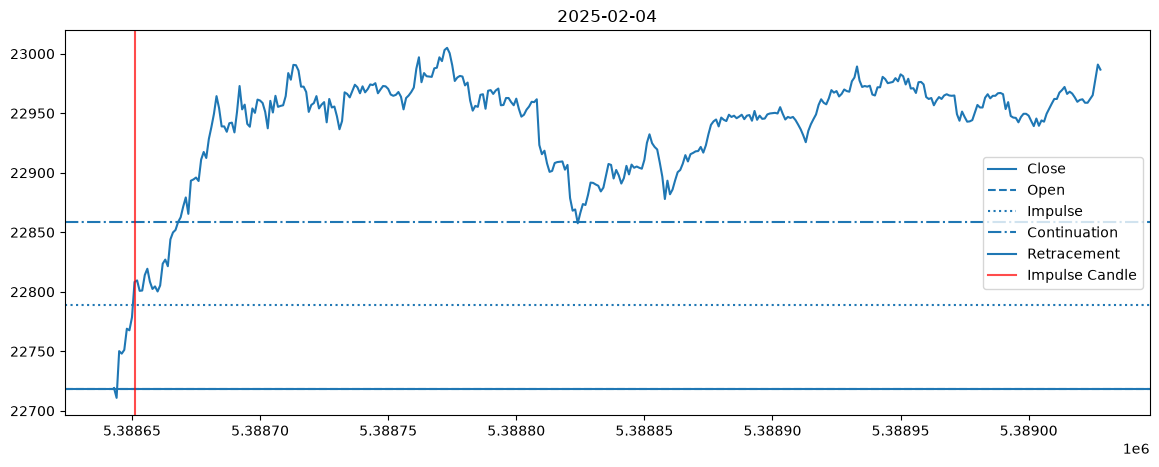

2022-12-29
Direction     : Up
Impulse index : 10
Outcome       : Neither


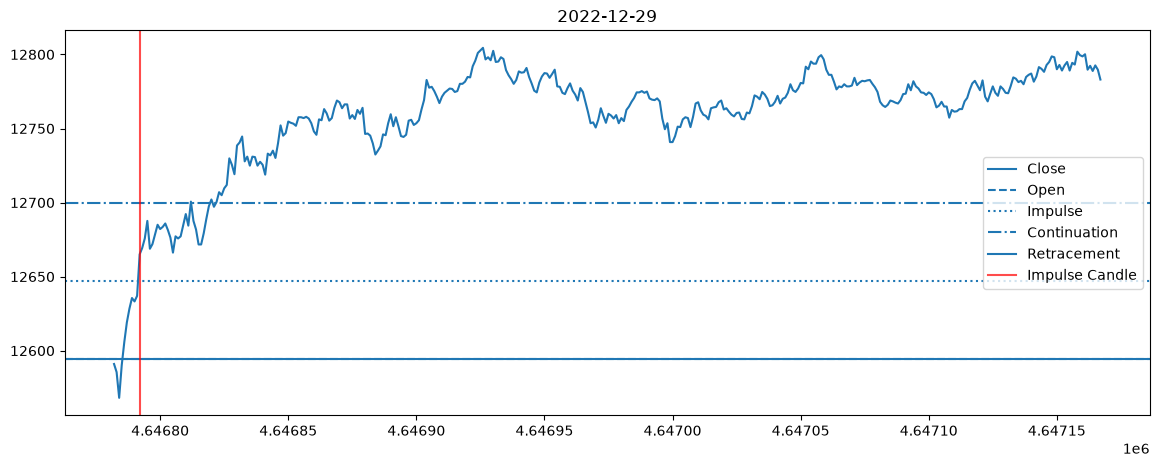

2022-08-25
Direction     : Down
Impulse index : 7
Outcome       : Retracement


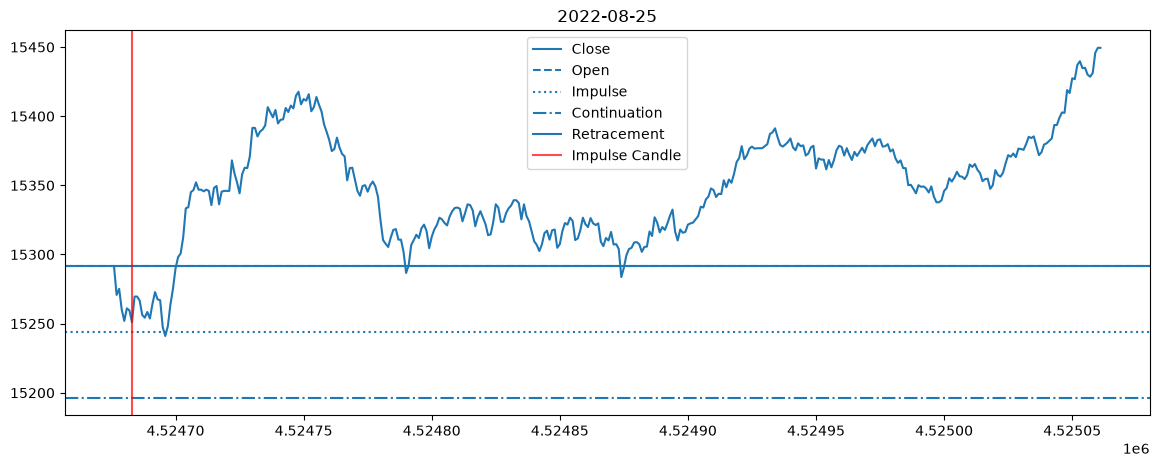

2025-07-02
Direction     : Up
Impulse index : 8
Outcome       : Neither


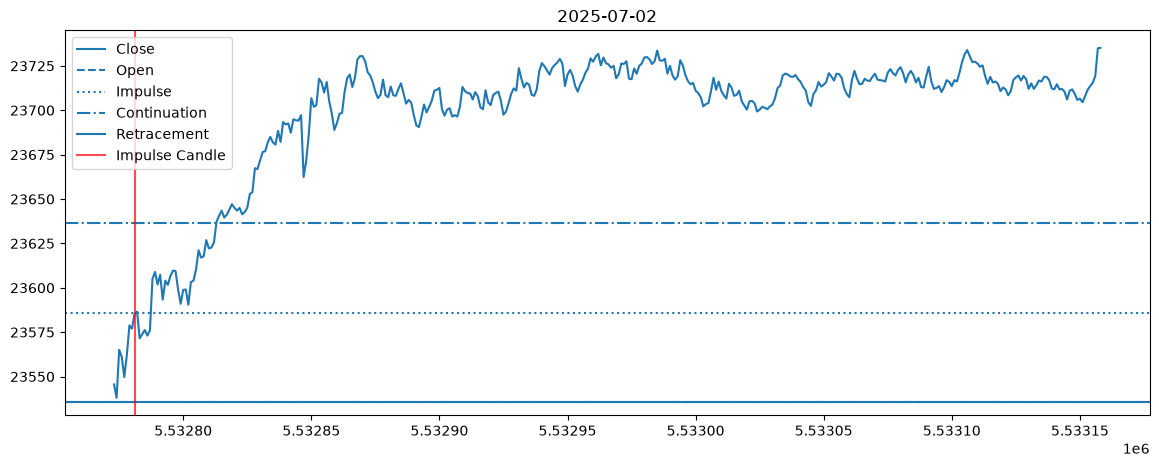

2023-08-23
Direction     : Up
Impulse index : 15
Outcome       : Continuation


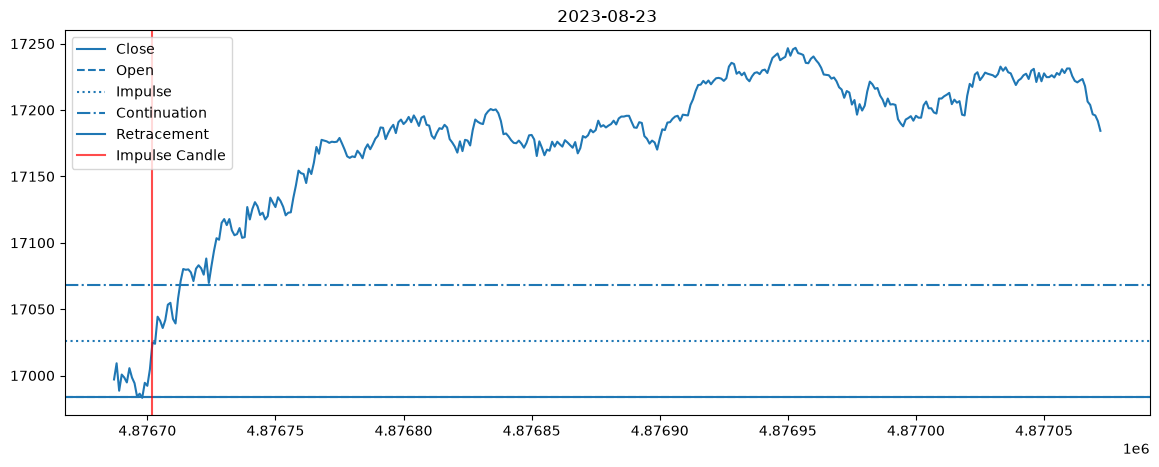

2023-07-11
Direction     : Up
Impulse index : 8
Outcome       : Retracement


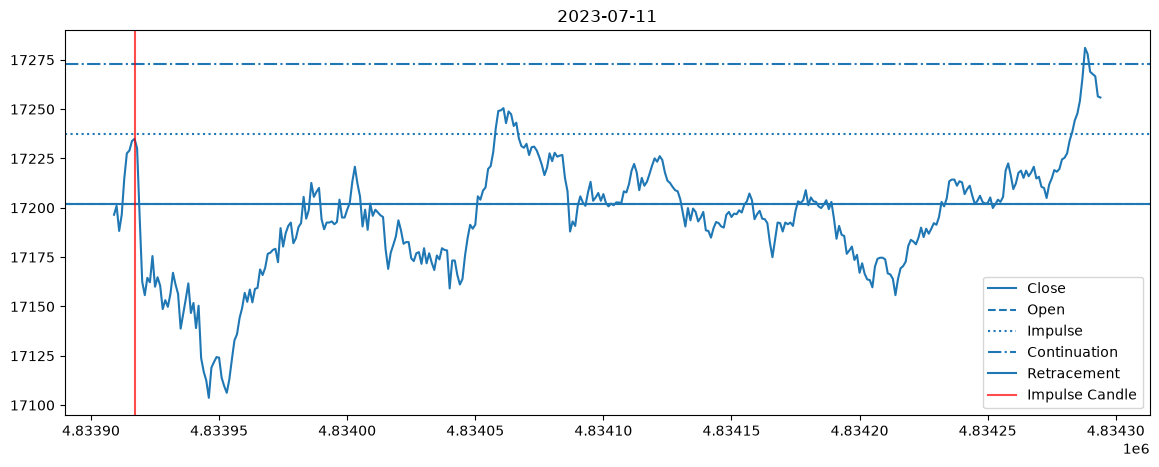

2023-06-09
Direction     : Up
Impulse index : 6
Outcome       : Retracement


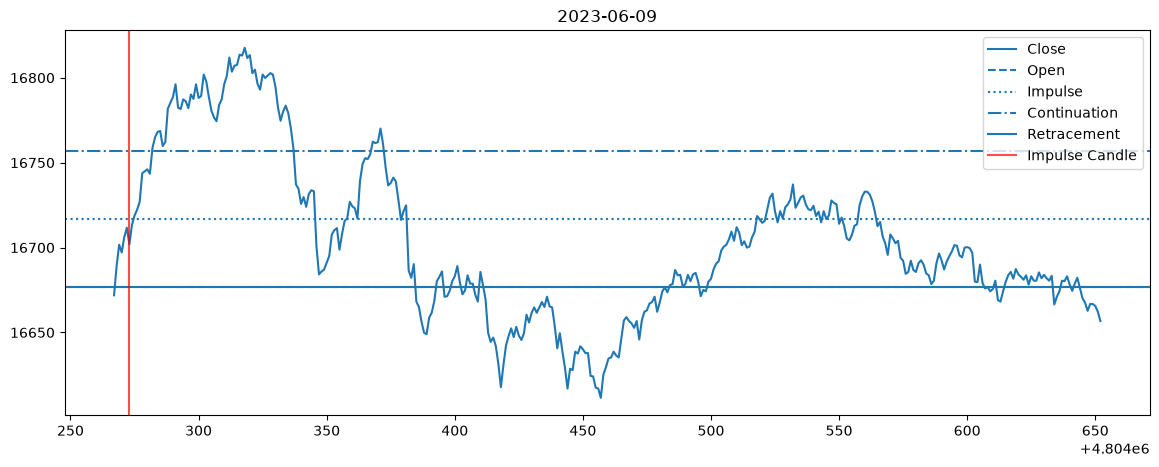

2023-02-08
Direction     : Down
Impulse index : 24
Outcome       : Retracement


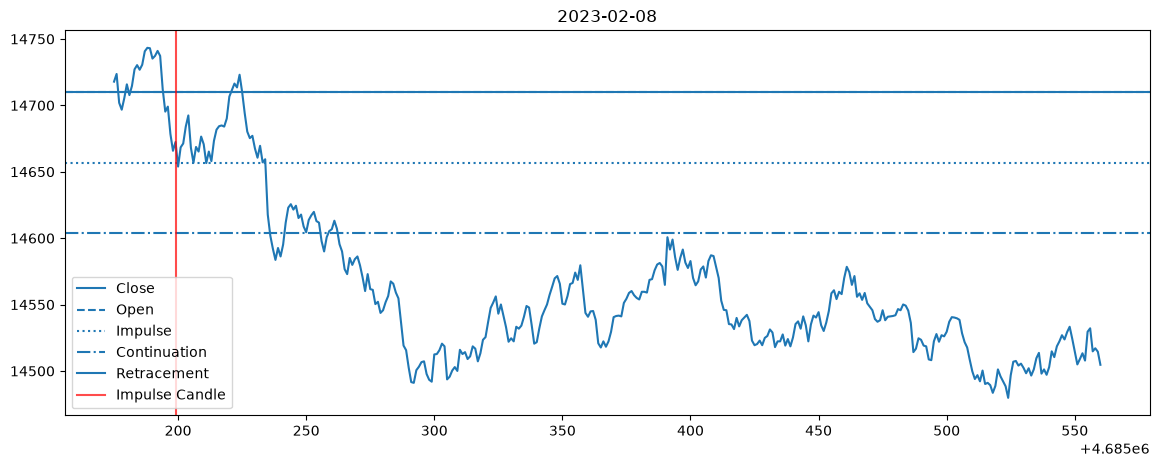

2025-06-25
Direction     : Down
Impulse index : 104
Outcome       : Neither


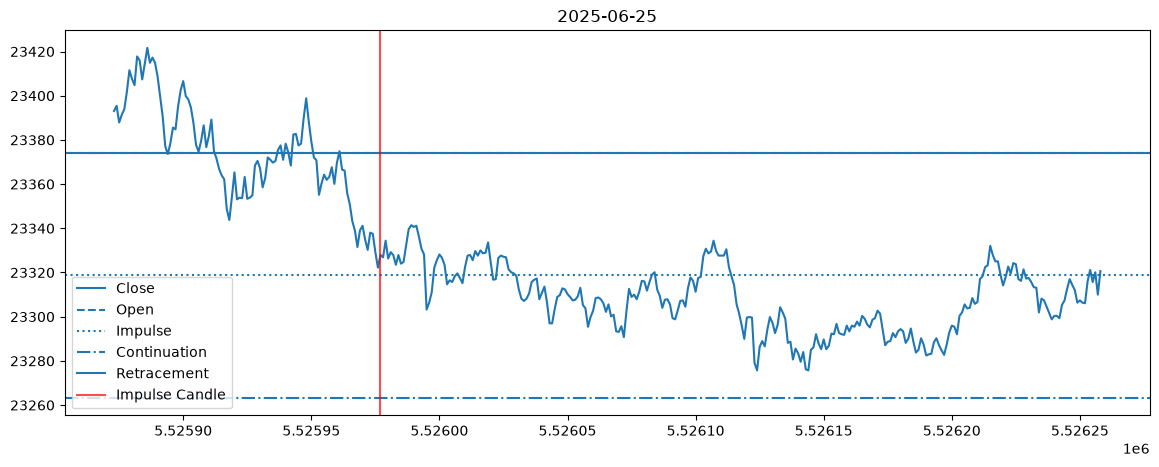

2022-12-14
Direction     : Up
Impulse index : 3
Outcome       : Retracement


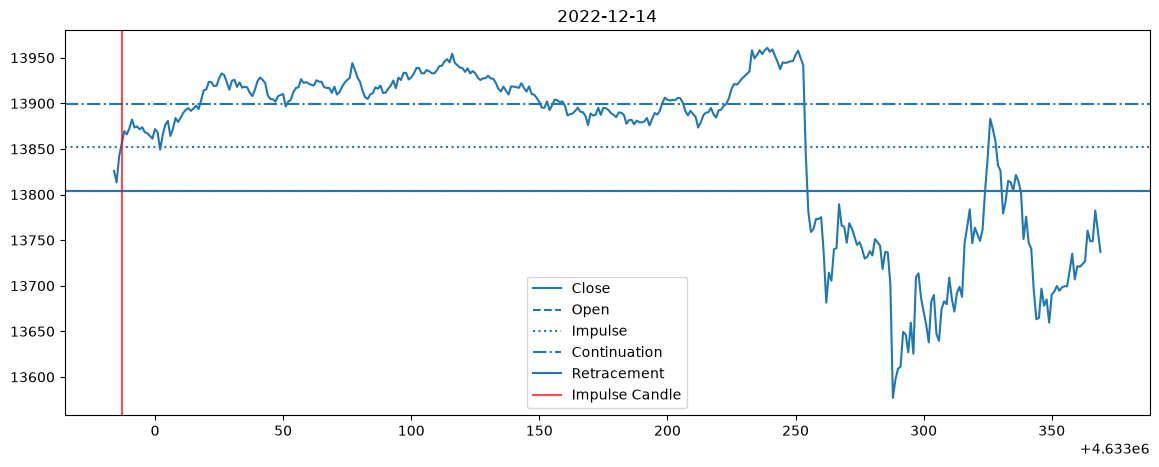

In [9]:
import random
import matplotlib.pyplot as plt

# ----------------------------------------
# SETTINGS
# ----------------------------------------

IMPULSE_PCT = 0.15
N = 10
random.seed(42)

# ----------------------------------------
# Sample sessions
# ----------------------------------------

valid_sessions = []

for session_date, session in df.groupby("SessionDate"):

    rth = session[
        (session["Datetime"].dt.time >= pd.to_datetime(RTH_START).time()) &
        (session["Datetime"].dt.time <= pd.to_datetime(RTH_END).time())
    ]

    if rth.empty:
        continue

    if pd.isna(rth.iloc[0]["ATR14"]):
        continue

    valid_sessions.append((session_date, rth))

samples = random.sample(valid_sessions, N)

# ----------------------------------------
# Validate
# ----------------------------------------

for session_date, rth in samples:

    direction, impulse_idx = first_impulse(rth, IMPULSE_PCT)

    if direction in ("Unknown", "Neither"):
        outcome = direction
    else:
        outcome = evaluate_after_impulse(
            rth,
            direction,
            impulse_idx,
            IMPULSE_PCT,
        )

    opening = rth.iloc[0]["open"]
    atr = rth.iloc[0]["ATR14"]
    impulse = atr * IMPULSE_PCT

    if direction == "Up":
        impulse_price = opening + impulse
        continuation = opening + 2 * impulse
        retracement = opening
    elif direction == "Down":
        impulse_price = opening - impulse
        continuation = opening - 2 * impulse
        retracement = opening
    else:
        impulse_price = None
        continuation = None
        retracement = opening

    print("=" * 80)
    print(session_date)
    print(f"Direction     : {direction}")
    print(f"Impulse index : {impulse_idx}")
    print(f"Outcome       : {outcome}")

    plt.figure(figsize=(14,5))

    plt.plot(
        rth.index,
        rth["close"],
        linewidth=1.5,
        label="Close"
    )

    plt.axhline(opening,
                linestyle="--",
                label="Open")

    if impulse_price is not None:
        plt.axhline(
            impulse_price,
            linestyle=":",
            label="Impulse"
        )

        plt.axhline(
            continuation,
            linestyle="-.",
            label="Continuation"
        )

        plt.axhline(
            retracement,
            linestyle="-",
            label="Retracement"
        )

        plt.axvline(
            rth.index[impulse_idx],
            color="red",
            alpha=0.7,
            label="Impulse Candle"
        )

    plt.title(str(session_date))
    plt.legend()
    plt.show()